# Project 5: Access and Waiting Time Analysis

# Objective

The objective of this project is to analyse appointment access patterns across primary care services in Hertfordshire and West Essex. The analysis focuses on waiting times, rapid-access appointments, appointment modes, and healthcare professional types to understand how quickly patients can access care and which service delivery methods contribute most to timely appointments.

By examining trends in rapid access and differences across appointment modes and workforce groups, this project aims to provide insights that support service planning, resource allocation, and improvements in patient access to care.


## Introduction

Timely access to primary care services is an important indicator of healthcare performance and patient experience. Long waiting times can delay treatment and reduce patient satisfaction, while rapid access can improve health outcomes and service efficiency.

This project explores appointment activity data from primary care services in Hertfordshire and West Essex. The analysis investigates overall waiting-time distributions, trends in rapid-access appointments, differences across appointment modes, and variations in access between healthcare professional groups.

The project seeks to identify patterns in appointment access and highlight factors associated with faster service delivery, providing a data-driven understanding of how primary care services meet patient demand.


## Questions

1. How has rapid access changed over time?

2. How do waiting-time distributions differ across appointment modes?

3. Which appointment modes contribute most to rapid-access appointments?

4. Do rapid-access rates differ by healthcare professional type?

5. Which appointment mode delivers the highest rapid-access rate?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/Regional_CSV_HertfordshireWEssex.csv")

In [3]:
df["TIME_BETWEEN_BOOK_AND_APPT"].value_counts()

TIME_BETWEEN_BOOK_AND_APPT
Same Day                  3046
2 to 7 Days               2960
1 Day                     2829
8  to 14 Days             2751
15  to 21 Days            2597
22  to 28 Days            2440
More than 28 Days         2317
Unknown / Data Quality    1104
Name: count, dtype: int64

## Access Overview

## Understanding Appointment Waiting Times

Before exploring changes in access over time, it is useful to understand the overall distribution of appointment waiting times across the dataset.

This provides a baseline view of how quickly patients are typically seen following appointment booking and helps establish the context for the analyses that follow.

In [4]:
waiting_time_df = (
    df.groupby("TIME_BETWEEN_BOOK_AND_APPT")[
        "COUNT_OF_APPOINTMENTS"
    ]
    .sum()
    .reset_index()
)

waiting_time_df["Percentage"] = (
    waiting_time_df["COUNT_OF_APPOINTMENTS"]
    / waiting_time_df["COUNT_OF_APPOINTMENTS"].sum()
    * 100
).round(2)

waiting_time_df = waiting_time_df.sort_values(
    "COUNT_OF_APPOINTMENTS",
    ascending=False
)

waiting_time_df

,TIME_BETWEEN_BOOK_AND_APPT,COUNT_OF_APPOINTMENTS,Percentage
6,Same Day,9738254,45.15
2,2 to 7 Days,3652592,16.93
4,8 to 14 Days,2739187,12.70
1,15 to 21 Days,1681130,7.79
0,1 Day,1492472,6.92
5,More than 28 Days,1130229,5.24
3,22 to 28 Days,1123198,5.21
7,Unknown / Data Quality,11776,0.05


### Finding

Appointment waiting times were heavily concentrated in the shortest access categories. Same-day appointments accounted for 45.15% of all appointments, making it the most common waiting-time category by a substantial margin.

A further 6.92% of appointments were delivered within one day, meaning that more than half of all appointments were delivered within 24 hours of booking. Longer waiting times were progressively less common, with appointments scheduled more than 28 days in advance accounting for just 5.24% of activity.

These findings suggest that rapid access forms a significant component of primary care service delivery across Hertfordshire and West Essex.

## Question 1: How Has Rapid Access Changed Over Time?

### Why This Question Matters

Rapid access to care is an important indicator of service responsiveness and patient access.

Monitoring changes in the proportion of appointments delivered within one day of booking can help identify whether access is improving, deteriorating, or remaining stable over time.

This analysis examines how the proportion of rapid-access appointments has changed throughout the study period.

In [5]:
# rapid access appointments
rapid_access = (
    df[
        df["TIME_BETWEEN_BOOK_AND_APPT"].isin(
            ["Same Day", "1 Day"]
        )
    ]
    .groupby("APPOINTMENT_MONTH")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

# total appointments
monthly_total = (
    df.groupby("APPOINTMENT_MONTH")["COUNT_OF_APPOINTMENTS"]
    .sum()
)

# rapid access percentage
rapid_access_rate = (
    rapid_access / monthly_total * 100
).round(2)

rapid_access_rate_df = rapid_access_rate.reset_index()

rapid_access_rate_df.columns = [
    "APPOINTMENT_MONTH",
    "Rapid_Access_Percentage"
]

rapid_access_rate_df

,APPOINTMENT_MONTH,Rapid_Access_Percentage
0,APR2024,53.05
1,APR2025,53.55
2,AUG2024,52.40
3,AUG2025,52.96
4,DEC2023,55.44
5,DEC2024,55.04
6,DEC2025,55.31
7,FEB2024,51.90
8,FEB2025,53.48
9,FEB2026,53.01


In [6]:
rapid_access_rate_df["APPOINTMENT_MONTH"] = pd.to_datetime(
    rapid_access_rate_df["APPOINTMENT_MONTH"],
    format="%b%Y"
)

rapid_access_rate_df = rapid_access_rate_df.sort_values(
    "APPOINTMENT_MONTH"
)

rapid_access_rate_df

,APPOINTMENT_MONTH,Rapid_Access_Percentage
25,2023-10-01,46.72
22,2023-11-01,51.17
4,2023-12-01,55.44
10,2024-01-01,53.80
7,2024-02-01,51.90
17,2024-03-01,52.14
0,2024-04-01,53.05
20,2024-05-01,53.31
15,2024-06-01,52.13
13,2024-07-01,52.07


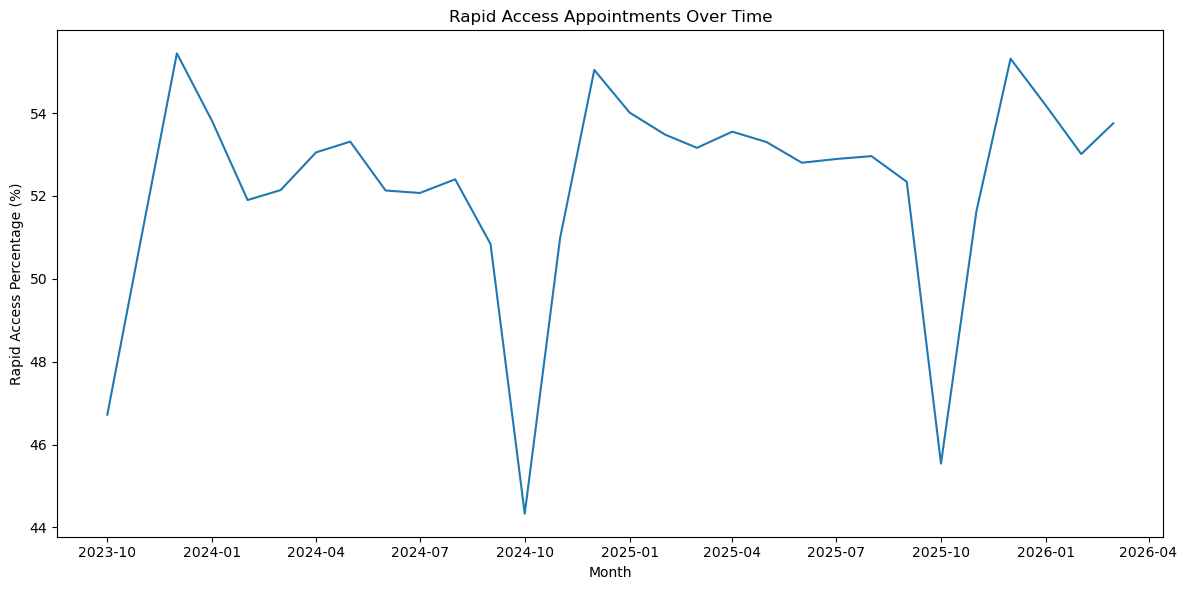

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    rapid_access_rate_df["APPOINTMENT_MONTH"],
    rapid_access_rate_df["Rapid_Access_Percentage"]
)

plt.title("Rapid Access Appointments Over Time")
plt.xlabel("Month")
plt.ylabel("Rapid Access Percentage (%)")

plt.tight_layout()
plt.show()

### Finding

Rapid access performance remained consistently stable throughout the study period, with approximately 50–55% of appointments being delivered on the same day or within one day of booking.

No clear long-term improvement or deterioration in access performance was observed. Instead, rapid-access rates remained relatively consistent across most months, suggesting stable service responsiveness over time.

A notable exception was October, which recorded the lowest rapid-access rates in each year analysed. This finding aligns with Project 4, where October consistently experienced the highest appointment demand. While the dataset cannot establish causation, the recurring pattern suggests that periods of elevated demand may place pressure on rapid-access availability.

Overall, the analysis indicates that primary care services maintained relatively stable access performance despite fluctuations in appointment demand.

### Do October appointments have longer waiting times than other months?

In [8]:
# create month name column

october_analysis = df.copy()

october_analysis["Month"] = october_analysis[
    "APPOINTMENT_MONTH"
].str[:3]

# label October vs Other Months

october_analysis["Month_Group"] = (
    october_analysis["Month"]
    .apply(lambda x: "October" if x == "OCT" else "Other Months")
)

# waiting-time distribution

october_waiting = (
    october_analysis
    .groupby(
        ["Month_Group", "TIME_BETWEEN_BOOK_AND_APPT"]
    )["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
)

# percentages within each group

october_waiting["Percentage"] = (
    october_waiting.groupby("Month_Group")[
        "COUNT_OF_APPOINTMENTS"
    ]
    .transform(
        lambda x: x / x.sum() * 100
    )
).round(2)

october_waiting

,Month_Group,TIME_BETWEEN_BOOK_AND_APPT,COUNT_OF_APPOINTMENTS,Percentage
0,October,1 Day,169372,6.48
1,October,15 to 21 Days,224295,8.58
2,October,2 to 7 Days,436816,16.70
3,October,22 to 28 Days,173513,6.63
4,October,8 to 14 Days,340234,13.01
5,October,More than 28 Days,249808,9.55
6,October,Same Day,1020149,39.00
7,October,Unknown / Data Quality,1333,0.05
8,Other Months,1 Day,1323100,6.98
9,Other Months,15 to 21 Days,1456835,7.69


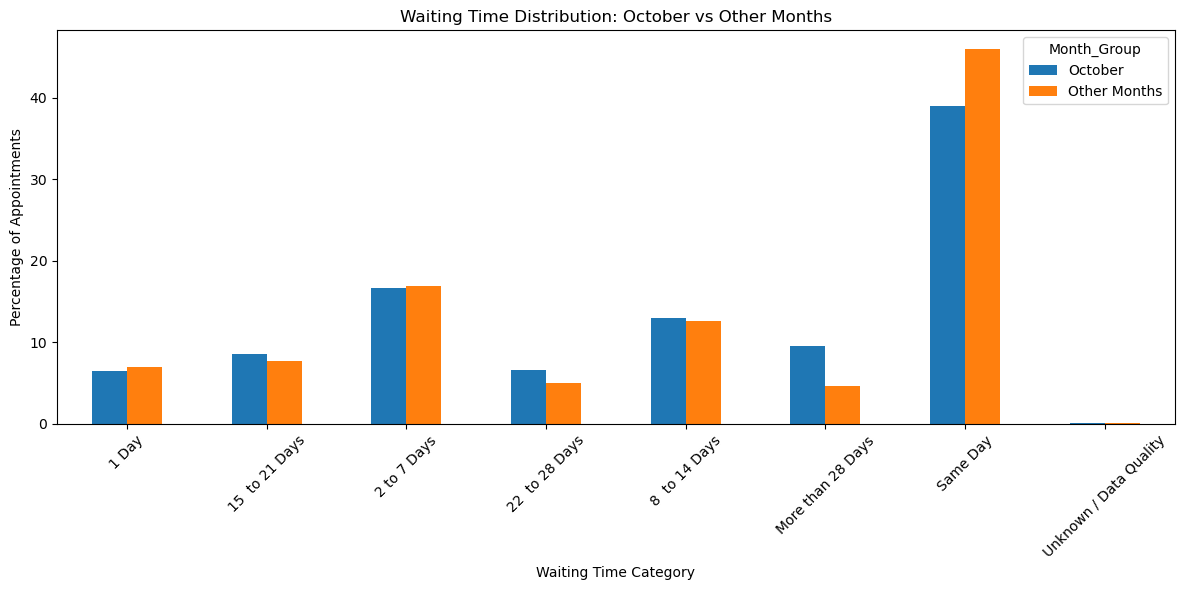

In [9]:
october_pivot = october_waiting.pivot(
    index="TIME_BETWEEN_BOOK_AND_APPT",
    columns="Month_Group",
    values="Percentage"
)

october_pivot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Waiting Time Distribution: October vs Other Months")
plt.xlabel("Waiting Time Category")
plt.ylabel("Percentage of Appointments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
october_pivot

Month_Group,October,Other Months
TIME_BETWEEN_BOOK_AND_APPT,,
1 Day,6.48,6.98
15 to 21 Days,8.58,7.69
2 to 7 Days,16.70,16.97
22 to 28 Days,6.63,5.01
8 to 14 Days,13.01,12.66
More than 28 Days,9.55,4.65
Same Day,39.00,46.00
Unknown / Data Quality,0.05,0.06


### Finding: October vs Other Months

To explore the recurring October pattern observed across the portfolio, waiting-time distributions were compared between October appointments and those in all other months.

The analysis found that October appointments were less likely to be delivered on the same day as booking, with same-day appointments accounting for 39.0% of October activity, compared with 46.0% in other months. Conversely, longer waiting times were more common in October, particularly for appointments scheduled more than 28 days after booking, which accounted for 9.55% of October appointments, compared with 4.65% in other months.

These findings suggest that periods of elevated demand may put pressure on immediate appointment availability, leading to a greater proportion of appointments scheduled further in the future. While the dataset cannot determine the underlying causes of this relationship, the pattern is consistent with findings from Project 4, in which October consistently emerged as the highest-demand month.

## Question 2: How Do Waiting-Time Distributions Differ Across Appointment Modes?

### Why This Question Matters

Different appointment modes may support different levels of patient access. Understanding how waiting times vary across consultation methods can help identify which appointment types are most commonly used to deliver rapid access and whether certain modes are associated with longer waits.

This analysis explores the relationship between appointment mode and waiting time distribution.

In [11]:
df["APPT_MODE"].value_counts()

APPT_MODE
Face-to-Face    4517
Unknown         4440
Telephone       4223
Home Visit      3627
Video/Online    3237
Name: count, dtype: int64

In [12]:
mode_waiting = (
    df.groupby(
        ["APPT_MODE", "TIME_BETWEEN_BOOK_AND_APPT"]
    )["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
)

mode_waiting["Percentage"] = (
    mode_waiting.groupby("APPT_MODE")[
        "COUNT_OF_APPOINTMENTS"
    ]
    .transform(
        lambda x: x / x.sum() * 100
    )
).round(2)

mode_waiting_pivot = mode_waiting.pivot(
    index="APPT_MODE",
    columns="TIME_BETWEEN_BOOK_AND_APPT",
    values="Percentage"
)

mode_waiting_pivot

TIME_BETWEEN_BOOK_AND_APPT,1 Day,15 to 21 Days,2 to 7 Days,22 to 28 Days,8 to 14 Days,More than 28 Days,Same Day,Unknown / Data Quality
APPT_MODE,,,,,,,,
Face-to-Face,6.40,9.08,18.23,6.16,14.57,6.28,39.23,0.04
Home Visit,15.22,1.64,15.45,0.98,3.68,1.43,60.93,0.68
Telephone,7.66,6.39,15.94,4.02,10.85,3.43,51.66,0.05
Unknown,6.64,3.92,11.67,2.58,6.80,3.17,65.10,0.13
Video/Online,9.04,0.99,8.37,0.66,2.19,1.95,76.74,0.07


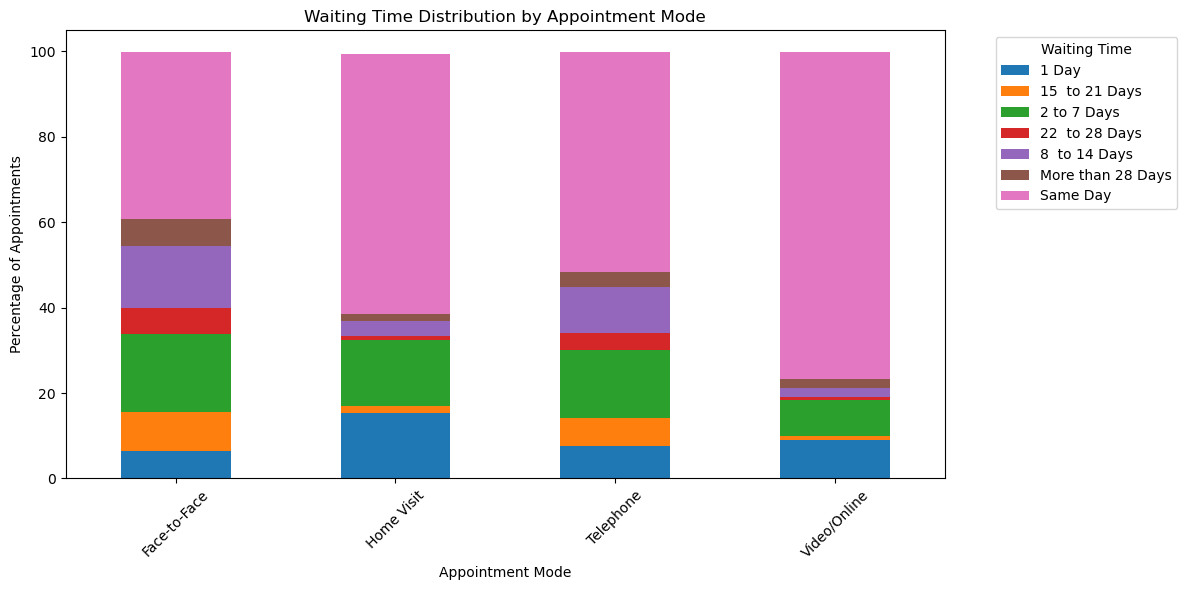

In [13]:
mode_waiting_chart = mode_waiting_pivot.drop(
    index="Unknown",
    columns="Unknown / Data Quality"
)

mode_waiting_chart.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Waiting Time Distribution by Appointment Mode")
plt.xlabel("Appointment Mode")
plt.ylabel("Percentage of Appointments")

plt.xticks(rotation=45)

plt.legend(
    title="Waiting Time",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

### Finding

Waiting-time distributions varied substantially across appointment modes.

Video/Online appointments demonstrated the highest level of rapid access, with 76.74% delivered on the same day of booking and fewer than 2% waiting longer than 28 days. Home visits also showed relatively high levels of same-day access (60.93%).

In contrast, Face-to-Face appointments exhibited the lowest same-day access rate (39.23%) and the highest proportion of longer waits, including appointments scheduled more than 28 days after booking (6.28%).

These findings suggest that appointment mode is associated with access speed, with remote consultation methods generally providing faster access than traditional face-to-face appointments.

## Question 3: Which Appointment Modes Contribute Most to Rapid-Access Appointments?

### Why This Matters

Rapid-access appointments are an important indicator of healthcare accessibility. Understanding which appointment modes contribute most to same-day and next-day appointments can help identify how primary care services deliver timely access to patients.

This analysis examines the contribution of different appointment modes to the provision of rapid-access appointments.

In [14]:
df["HCP_TYPE"].value_counts()

HCP_TYPE
Other Practice staff    8583
GP                      8232
Unknown                 3229
Name: count, dtype: int64

In [15]:
rapid_access_modes = (
    df[
        df["TIME_BETWEEN_BOOK_AND_APPT"].isin(
            ["Same Day", "1 Day"]
        )
    ]
    .groupby("APPT_MODE")["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
)

rapid_access_modes["Percentage"] = (
    rapid_access_modes["COUNT_OF_APPOINTMENTS"]
    / rapid_access_modes["COUNT_OF_APPOINTMENTS"].sum()
    * 100
).round(2)

rapid_access_modes = rapid_access_modes.sort_values(
    "Percentage",
    ascending=False
)

rapid_access_modes

,APPT_MODE,COUNT_OF_APPOINTMENTS,Percentage
0,Face-to-Face,6600123,58.77
2,Telephone,3035530,27.03
4,Video/Online,983778,8.76
3,Unknown,473473,4.22
1,Home Visit,137822,1.23


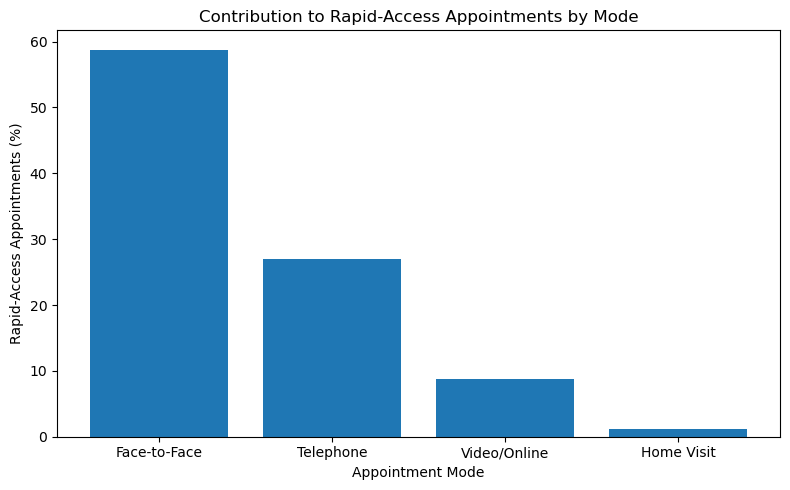

In [16]:
rapid_access_modes_chart = (
    rapid_access_modes[
        rapid_access_modes["APPT_MODE"] != "Unknown"
    ]
)
    
plt.figure(figsize=(8,5))

plt.bar(
    rapid_access_modes_chart["APPT_MODE"],
    rapid_access_modes_chart["Percentage"]
)

plt.title("Contribution to Rapid-Access Appointments by Mode")
plt.xlabel("Appointment Mode")
plt.ylabel("Rapid-Access Appointments (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Finding

Face-to-Face appointments accounted for the majority of rapid-access appointments, contributing 58.77% of all same-day and next-day appointments during the study period.

Telephone appointments represented the second-largest contributor (27.03%), while Video/Online appointments accounted for 8.76%. Home Visits contributed only 1.23% of rapid-access appointments.

Although Video/Online appointments demonstrated the highest same-day access rates in Question 2, Face-to-Face appointments remained the primary mechanism for delivering rapid-access care due to their substantially larger appointment volumes.

## Question 4: Do Rapid-Access Rates Differ by Healthcare Professional Type?

### Why This Matters

Healthcare services are delivered by a range of professional groups, including General Practitioners (GPs) and other practice staff. Understanding whether rapid-access appointments are distributed differently across these workforce groups can provide insights into how primary care teams support timely patient access.

This analysis compares rapid-access appointment rates across healthcare professional types.

In [17]:
hcp_access = (
    df.groupby("HCP_TYPE")["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
    .rename(columns={"COUNT_OF_APPOINTMENTS": "Total_Appointments"})
)

hcp_rapid = (
    df[
        df["TIME_BETWEEN_BOOK_AND_APPT"].isin(
            ["Same Day", "1 Day"]
        )
    ]
    .groupby("HCP_TYPE")["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
    .rename(columns={"COUNT_OF_APPOINTMENTS": "Rapid_Access_Appointments"})
)

hcp_access = hcp_access.merge(
    hcp_rapid,
    on="HCP_TYPE"
)

hcp_access["Rapid_Access_Rate"] = (
    hcp_access["Rapid_Access_Appointments"]
    / hcp_access["Total_Appointments"]
    * 100
).round(2)

hcp_access.sort_values(
    "Rapid_Access_Rate",
    ascending=False
)

,HCP_TYPE,Total_Appointments,Rapid_Access_Appointments,Rapid_Access_Rate
2,Unknown,493557,387800,78.57
0,GP,11151727,6961174,62.42
1,Other Practice staff,9923554,3881752,39.12


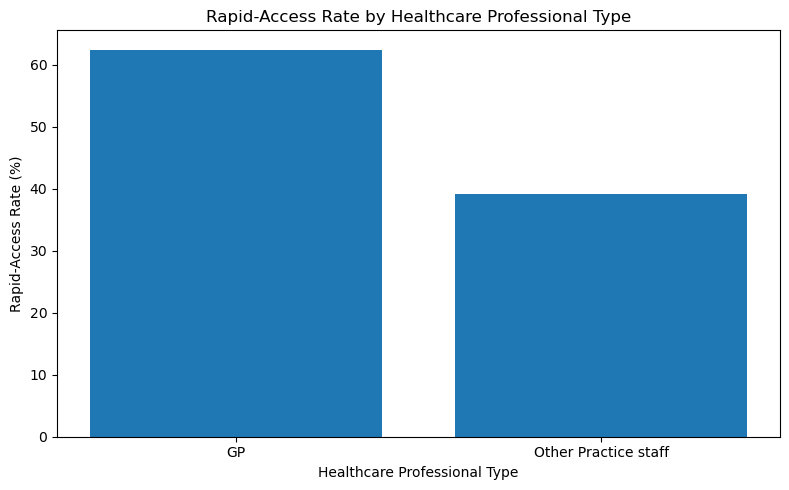

In [18]:
hcp_chart = hcp_access[
    hcp_access["HCP_TYPE"] != "Unknown"
]

plt.figure(figsize=(8,5))

plt.bar(
    hcp_chart["HCP_TYPE"],
    hcp_chart["Rapid_Access_Rate"]
)

plt.title("Rapid-Access Rate by Healthcare Professional Type")
plt.xlabel("Healthcare Professional Type")
plt.ylabel("Rapid-Access Rate (%)")

plt.tight_layout()
plt.show()

### Finding

GPs delivered both the highest volume and the highest proportion of rapid-access appointments among identified healthcare professional groups.

GPs recorded 6.96 million rapid-access appointments, representing 62.42% of all GP appointments. In comparison, Other Practice Staff delivered 3.88 million rapid-access appointments, representing 39.12% of their total activity.

A further 493,557 appointments were recorded with an unknown healthcare professional type. Although this group exhibited a high rapid-access rate (78.57%), the lack of classification limits interpretation and highlights a potential data-quality issue within the dataset.

These findings suggest that GPs play a central role in delivering rapid-access care across the region.

## Question 5: Which Appointment Mode Delivers the Highest Rapid-Access Rate?

### Why This Matters

While some appointment modes may deliver a large number of rapid-access appointments, this does not necessarily mean they provide the fastest access to patients.

Measuring the rapid-access rate allows us to evaluate how effectively each appointment mode delivers same-day or 1-day appointments, regardless of overall appointment volume.

This analysis helps identify which consultation methods provide the most timely access to care and highlights opportunities to improve service delivery.

In [19]:
rapid_access_mode = (
    df[
        df["TIME_BETWEEN_BOOK_AND_APPT"].isin(
            ["Same Day", "1 Day"]
        )
    ]
    .groupby("APPT_MODE")["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "COUNT_OF_APPOINTMENTS":
            "Rapid_Access_Appointments"
        }
    )
)

total_mode = (
    df.groupby("APPT_MODE")["COUNT_OF_APPOINTMENTS"]
    .sum()
    .reset_index()
    .rename(
        columns={
            "COUNT_OF_APPOINTMENTS":
            "Total_Appointments"
        }
    )
)

mode_access = total_mode.merge(
    rapid_access_mode,
    on="APPT_MODE"
)

mode_access["Rapid_Access_Rate"] = (
    mode_access["Rapid_Access_Appointments"]
    /
    mode_access["Total_Appointments"]
    * 100
).round(2)

mode_access.sort_values(
    "Rapid_Access_Rate",
    ascending=False
)

,APPT_MODE,Total_Appointments,Rapid_Access_Appointments,Rapid_Access_Rate
4,Video/Online,1146854,983778,85.78
1,Home Visit,180998,137822,76.15
3,Unknown,660028,473473,71.74
2,Telephone,5116714,3035530,59.33
0,Face-to-Face,14464244,6600123,45.63


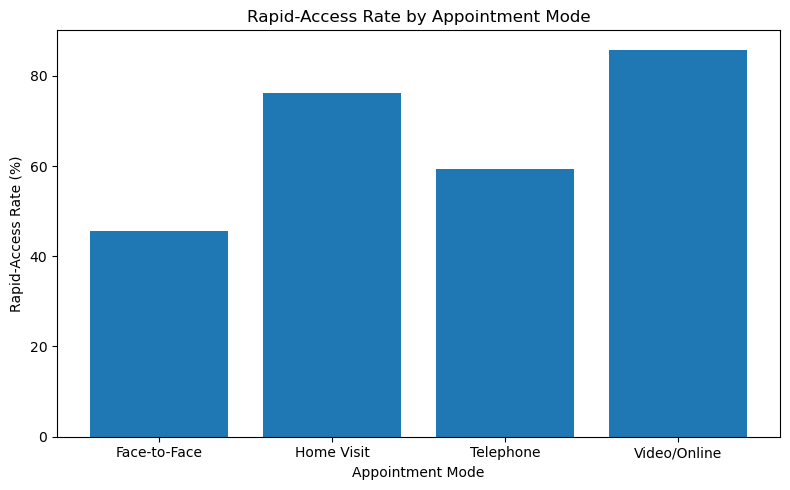

In [20]:
mode_chart = mode_access[
    mode_access["APPT_MODE"] != "Unknown"
]

plt.figure(figsize=(8,5))

plt.bar(
    mode_chart["APPT_MODE"],
    mode_chart["Rapid_Access_Rate"]
)

plt.title("Rapid-Access Rate by Appointment Mode")
plt.xlabel("Appointment Mode")
plt.ylabel("Rapid-Access Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Finding

Rapid-access rates varied considerably across appointment modes.

Video/Online appointments achieved the highest rapid-access rate, with approximately 86% of appointments delivered on the same day or within one day of booking. Home Visits also demonstrated high levels of rapid access (approximately 76%), followed by Telephone appointments (approximately 60%).

Face-to-Face appointments recorded the lowest rapid-access rate (approximately 46%). However, findings from Question 3 showed that Face-to-Face appointments still contributed the majority of all rapid-access appointments due to their substantially higher appointment volumes.

These results suggest that remote consultation methods provide the fastest access to care, while Face-to-Face appointments remain the primary channel through which rapid-access services are delivered.

## Key Findings

- Most appointments were delivered quickly, with same-day appointments representing the largest waiting-time category and the majority of appointments occurring within seven days of booking.

- Rapid-access levels remained relatively stable throughout the study period, although October consistently recorded lower rapid-access percentages than other months.

- Waiting-time distributions differed substantially across appointment modes. Video/Online appointments demonstrated the highest proportion of same-day appointments, while Face-to-Face appointments showed a larger share of longer waiting times.

- Face-to-Face appointments accounted for the majority of all rapid-access appointments despite having lower rapid-access rates than other appointment modes. This reflects the substantially higher volume of Face-to-Face activity.

- GPs delivered both the highest volume and the highest proportion of rapid-access appointments among identified healthcare professional groups, highlighting their central role in providing timely access to care.

- Video/Online appointments achieved the highest rapid-access rate, followed by Home Visits and Telephone appointments. These findings suggest that remote consultation methods provide the fastest route to care, while Face-to-Face appointments remain the primary channel for delivering rapid-access services.

- A proportion of appointments were classified as Unknown across some variables, indicating potential data-quality limitations that should be considered when interpreting workforce-level findings.

## Conclusion

This project examined access and waiting-time patterns across primary care services in Hertfordshire and West Essex. The findings indicate that rapid access is consistently maintained, with a substantial proportion of appointments delivered on the same day or within one day of booking.

Appointment mode emerged as an important factor influencing access. Video/Online appointments achieved the highest rapid-access rates, demonstrating the effectiveness of remote consultation methods in providing timely care. However, Face-to-Face appointments remained the largest contributor to rapid-access activity due to their significantly higher appointment volumes.

Workforce analysis showed that GPs play a leading role in delivering rapid-access care, both in terms of appointment volume and rapid-access performance. Together, these findings suggest that timely access is supported by a combination of high-volume Face-to-Face services and efficient remote consultation methods.

Overall, the analysis demonstrates how appointment mode and workforce composition influence patient access to care and provides evidence that can support future service planning and operational decision-making.
